In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [3]:
df=pd.read_csv('Loan_status_2007-2020Q3.gzip')

C:\Users\admin\AppData\Local\Temp\ipykernel_8804\4019579964.py:1: DtypeWarning: Columns (1,48,58,117,127,128,129,132,133,134,137) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('Loan_status_2007-2020Q3.gzip')


In [8]:
print(df.columns)
print("Total Features:", len(df.columns))

Index(['Unnamed: 0', 'id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'hardship_start_date', 'hardship_end_date', 'payment_plan_start_date',
       'hardship_length', 'hardship_dpd', 'hardship_loan_status',
       'orig_projected_additional_accrued_interest',
       'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
       'debt_settlement_flag'],
      dtype='object', length=142)
Total Features: 142


In [10]:
df.describe()

,Unnamed: 0,loan_amnt,funded_amnt,funded_amnt_inv,installment,annual_inc,dti,delinq_2yrs,fico_range_low,fico_range_high,...,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,deferral_term,hardship_amount,hardship_length,hardship_dpd,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount
count,2.925493e+06,2.925492e+06,2.925492e+06,2.925492e+06,2.925492e+06,2.925488e+06,2.922384e+06,2.925463e+06,2.925492e+06,2.925492e+06,...,197824.000000,197824.000000,197824.000000,143638.000000,182076.000000,143638.000000,143637.000000,179240.000000,182076.000000,182076.000000
mean,8.697419e+04,1.535878e+04,1.535470e+04,1.534005e+04,4.523914e+02,7.993727e+04,1.929648e+01,2.897012e-01,7.005110e+02,7.045112e+02,...,12.544398,0.038327,0.067545,2.233427,119.887400,2.233427,2.323148,369.367460,11993.128927,745.504875
std,8.048842e+04,9.478383e+03,9.477145e+03,9.480634e+03,2.729478e+02,1.117476e+05,1.571977e+01,8.436819e-01,3.376565e+01,3.376653e+01,...,8.206977,0.362390,0.371836,0.565689,247.522976,0.565689,6.179453,468.696526,9162.902724,2095.316599
min,0.000000e+00,5.000000e+02,5.000000e+02,0.000000e+00,4.930000e+00,0.000000e+00,-1.000000e+00,0.000000e+00,6.100000e+02,6.140000e+02,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.284100e+04,8.000000e+03,8.000000e+03,8.000000e+03,2.535000e+02,4.700000e+04,1.208000e+01,0.000000e+00,6.750000e+02,6.790000e+02,...,7.000000,0.000000,0.000000,2.000000,0.000000,2.000000,0.000000,104.280000,4749.142500,259.040000
50%,6.892500e+04,1.300000e+04,1.300000e+04,1.300000e+04,3.823000e+02,6.600000e+04,1.810000e+01,0.000000e+00,6.950000e+02,6.990000e+02,...,11.000000,0.000000,0.000000,2.000000,0.000000,2.000000,0.000000,249.474420,9967.160000,423.200000
75%,1.072940e+05,2.000000e+04,2.000000e+04,2.000000e+04,6.039200e+02,9.500000e+04,2.488000e+01,0.000000e+00,7.200000e+02,7.240000e+02,...,17.000000,0.000000,0.000000,2.000000,101.940000,2.000000,0.000000,482.532500,17640.670000,679.580000
max,4.210940e+05,4.000000e+04,4.000000e+04,4.000000e+04,1.719830e+03,1.100000e+08,9.990000e+02,5.800000e+01,8.450000e+02,8.500000e+02,...,121.000000,21.000000,23.000000,4.000000,2797.500000,4.000000,82.000000,11581.820000,42135.550000,40270.980000


In [12]:
columns_to_drop = ["id", "member_id", "url", "desc", "emp_title"]
df.drop(columns=columns_to_drop, axis=1, inplace=True, errors='ignore')

In [13]:
print(df.isnull().sum().sum())

107629143


In [15]:
missing_percentage = df.isnull().mean() * 100
high_null_cols = missing_percentage[missing_percentage > 50].index.tolist()
df.drop(columns=high_null_cols, axis=1, inplace=True)

In [17]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna("Unknown", inplace=True)  
    else:
        df[col].fillna(df[col].median(), inplace=True)

C:\Users\admin\AppData\Local\Temp\ipykernel_8804\4245806161.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\admin\AppData\Local\Temp\ipykernel_8804\4245806161.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

In [18]:
cat_cols = df.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [19]:
print(df.isnull().sum().sum())

0


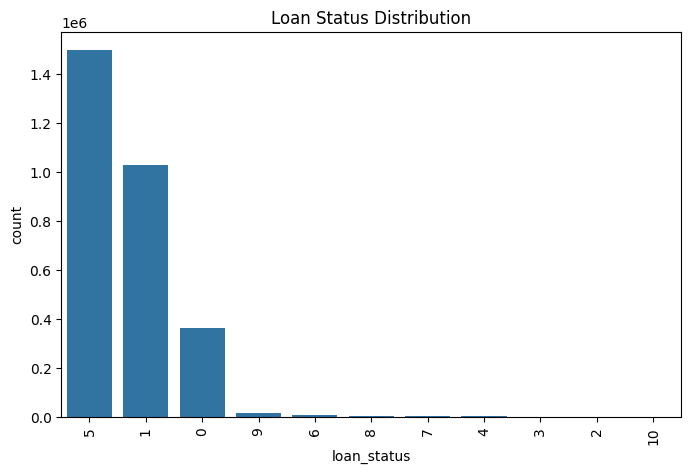

In [12]:
plt.figure(figsize=(8, 5))
sns.countplot(x='loan_status', data=df, order=df['loan_status'].value_counts().index)
plt.title("Loan Status Distribution")
plt.xticks(rotation=90)
plt.show()

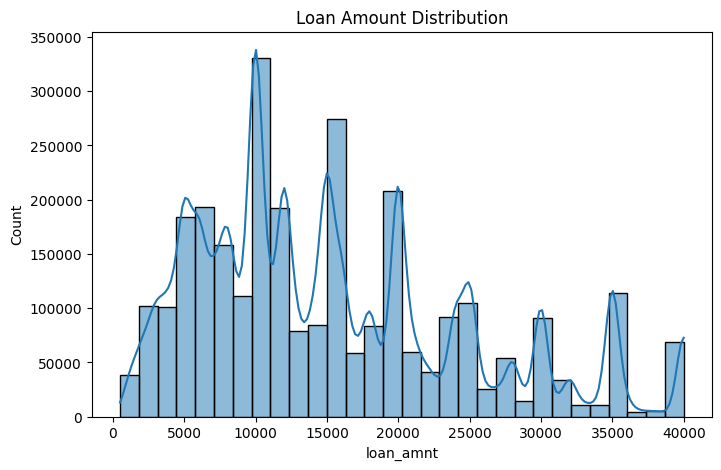

In [13]:
plt.figure(figsize=(8, 5))
sns.histplot(df['loan_amnt'], bins=30, kde=True)
plt.title("Loan Amount Distribution")
plt.show()

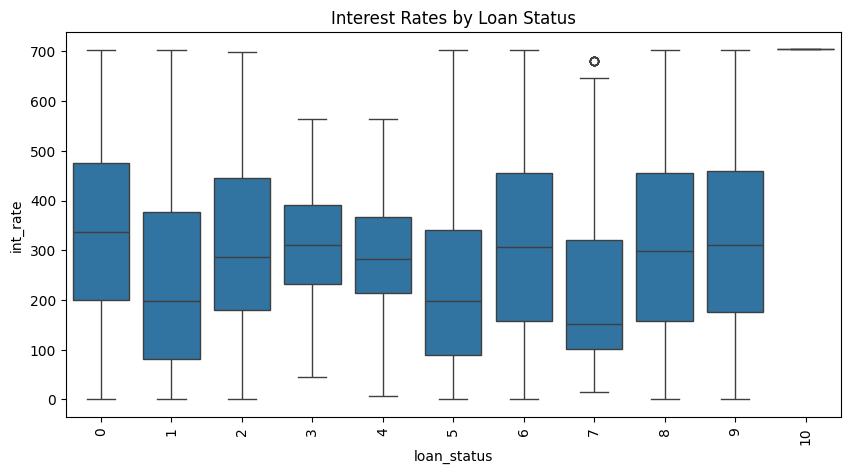

In [14]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='loan_status', y='int_rate', data=df)
plt.title("Interest Rates by Loan Status")
plt.xticks(rotation=90)
plt.show()

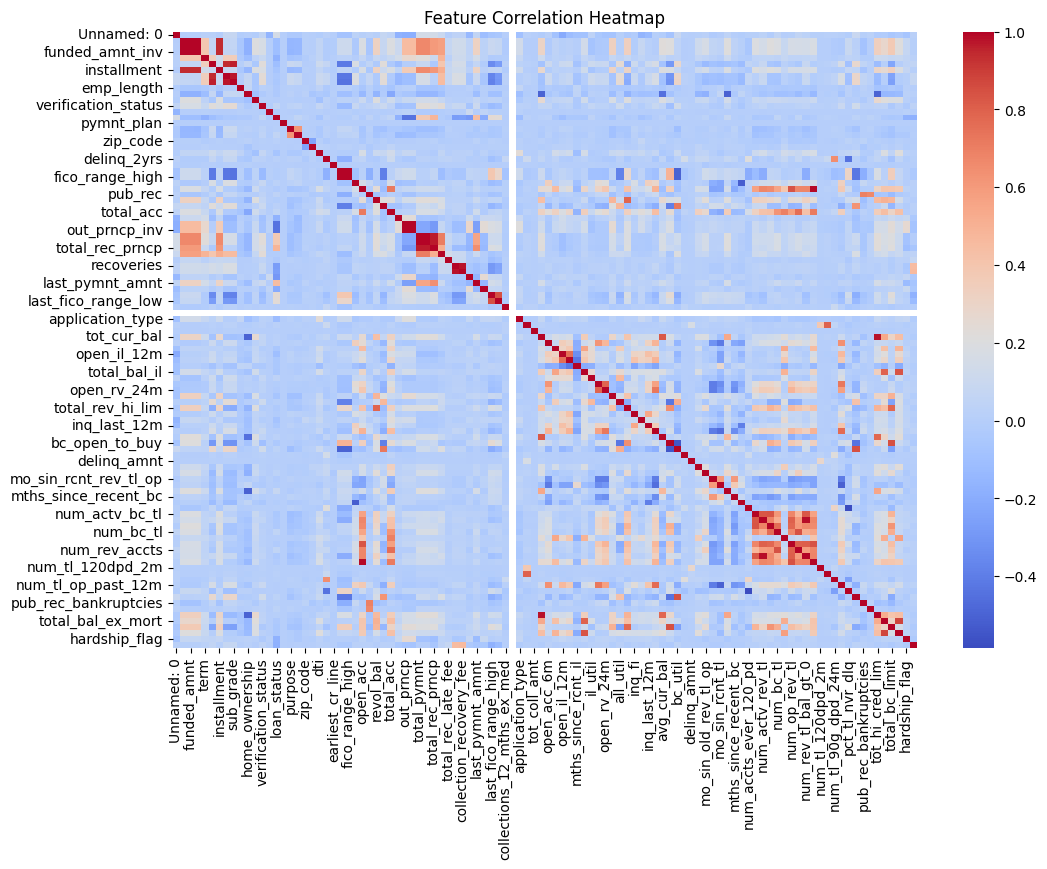

In [15]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

In [24]:
cat_cols = df.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [36]:
print([col for col in df.columns if "fico" in col.lower() or "credit" in col.lower()])


['fico_range_low', 'fico_range_high', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'total_il_high_credit_limit']


In [40]:
selected_features = ["loan_amnt", "int_rate", "installment", "annual_inc", "dti", 
                     "open_acc", "pub_rec", "revol_bal", "revol_util", "total_acc", 
                     "mort_acc", "credit_score"]

In [38]:
df["credit_score"] = (df["fico_range_low"] + df["fico_range_high"]) / 2


In [42]:
X = df[selected_features]
y = df["loan_status"]


In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [46]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [48]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
}


In [50]:
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"{name} Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred))
    print("-" * 50)

Training Random Forest...
Random Forest Accuracy: 0.6653


C:\Users\admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.38      0.04      0.08     72588
           1       0.68      0.65      0.66    206215
           2       0.00      0.00      0.00        89
           3       1.00      0.01      0.01       148
           4       0.69      0.12      0.20       376
           5       0.66      0.84      0.74    299596
           6       0.00      0.00      0.00      1943
           7       0.00      0.00      0.00       377
           8       0.00      0.00      0.00       530
           9       0.00      0.00      0.00      3237

    accuracy                           0.67    585099
   macro avg       0.34      0.17      0.17    585099
weighted avg       0.63      0.67      0.62    585099

--------------------------------------------------


In [22]:
ann_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

print("ann model")
ann_model.summary()

ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
ann_model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))


y_pred_ann = (ann_model.predict(X_test) > 0.5).astype("int32")
print("ANN Accuracy:", accuracy_score(y_test, y_pred_ann))
print(classification_report(y_test, y_pred_ann))

ann model


C:\Users\admin\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        13,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,193 (94.50 KB)

...

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
73138/73138 ━━━━━━━━━━━━━━━━━━━━ 121s 2ms/step - accuracy: 0.3523 - loss: -4686326863495168.0000 - val_accuracy: 0.3524 - val_loss: -134709278417092608.0000
Epoch 2/10
73138/73138 ━━━━━━━━━━━━━━━━━━━━ 115s 2ms/step - accuracy: 0.3524 - loss: -477720622399488000.0000 - val_accuracy: 0.3524 - val_loss: -3163097590774366208.0000
Epoch 3/10
73138/73138 ━━━━━━━━━━━━━━━━━━━━ 122s 2ms/step - accuracy: 0.3521 - loss: -5979031531904040960.0000 - val_accuracy: 0.3524 - val_loss: -21140965376179306496.0000
Epoch 4/10
73138/73138 ━━━━━━━━━━━━━━━━━━━━ 115s 2ms/step - accuracy: 0.3529 - loss: -32246963003554004992.0000 - val_accuracy: 0.3524 - val_loss: -82912342263239540736.0000
Epoch 5/10
73138/73138 ━━━━━━━━━━━━━━━━━━━━ 131s 2ms/step - accuracy: 0.3530 - loss: -113632943433905602560.0000 - val_accuracy: 0.3524 - val_loss: -241483557377373372416.0000
Epoch 6/10
73138/73138 ━━━━━━━━━━━━━━━━━━━━ 143s 2ms/step - accuracy: 0.3521 - loss: -310885663708454846464.0000 - val_accuracy: 0.3524 - 

C:\Users\admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00     72588
           1       0.35      1.00      0.52    206215
           2       0.00      0.00      0.00        89
           3       0.00      0.00      0.00       148
           4       0.00      0.00      0.00       376
           5       0.00      0.00      0.00    299596
           6       0.00      0.00      0.00      1943
           7       0.00      0.00      0.00       377
           8       0.00      0.00      0.00       530
           9       0.00      0.00      0.00      3237

    accuracy                           0.35    585099
   macro avg       0.04      0.10      0.05    585099
weighted avg       0.12      0.35      0.18    585099



C:\Users\admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [62]:
import joblib
from sklearn.ensemble import RandomForestClassifier

# Train your model (example)
model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train, y_train)  # Make sure you define X_train, y_train properly

# ✅ Save the trained model with compression
joblib.dump(model, "D:/modell.pkl", compress=3)
print("✅ Model saved successfully!")


✅ Model saved successfully!
